# Assignment 2 — Part B: Managerial User Study
## Would managers trust an AI to tell them who might leave?

After building the **ABC Ltd Employee Retention Advisor**, 32 decision-makers (managers, team leaders, supervisors, entrepreneurs, working professionals and senior decision-makers) reviewed the tool and answered a mixed-method survey:
- **18 Likert items** measuring 8 constructs (usefulness, ease of use, trust, explainability, fear of a wrong decision, preference for intuition, organisational support, intention to use)
- **1 scenario** where the AI and the manager's experience disagree
- **11 open-ended questions**

> ⚠️ **Data note:** the responses in `survey_responses.csv` are **synthetic placeholder data** generated by `generate_synthetic_survey.py` to build and test this analysis. Replace the file with your real Google Form export (same column names) and re-run every cell — all tables, charts and themes will update.

## 1. Load data

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
sns.set_theme(style="whitegrid")

# Works in Colab (reads from your GitHub repo) and locally (reads the file next to the notebook)
GITHUB_CSV = "https://raw.githubusercontent.com/<your-username>/abc-retention-advisor/main/survey/survey_responses.csv"
LOCAL = [p for p in ["survey_responses.csv", "../survey/survey_responses.csv", "survey/survey_responses.csv"] if os.path.exists(p)]
df = pd.read_csv(LOCAL[0] if LOCAL else GITHUB_CSV)
print(df.shape)
df.head(3)

(32, 37)


,RespondentID,Role,ExperienceYears,Sector,TeamSize,AIUseFrequency,ReviewMode,PU1,PU2,PU3,...,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11
0,R01,Manager,11,Banking & NBFC,50+,Monthly,Used it myself,5,4,4,...,"I would, especially for new joiners in the fir...",The team view and the download option.,"Needs a confidence range, not just one percent...","Yes, since it's tested on past data and the ac...",A confidence range and a note when the data is...,Treat the disagreement as a signal to dig deep...,Intuition is faster; the tool needs inputs and...,"Somewhat. Explanations help, but they also nee...","Yes, especially because I'll be blamed, not th...",Poor data quality and outdated HR records. Too...
1,R02,Team Leader,6,Banking & NBFC,6–15,Monthly,Used it myself,4,3,4,...,"Maybe, as a second opinion, not the main basis...",The blue line showing the company average give...,No option to save an employee and compare later.,I'd trust it more after seeing it run on my ow...,Knowing who built it and how it is monitored.,Look at which factor is driving the score and ...,"Because people decisions are personal, and a n...",Definitely. The drivers section is the reason ...,"Yes, which is why I'd use it only to start a c...",Too many disconnected systems — one more tool ...
2,R03,Working Professional,4,IT services,1–5,Monthly,Used it myself,4,3,4,...,"Only if HR also uses it, so we're looking at t...","It admits it can be wrong, which I appreciate.",Some suggested actions are generic.,To some extent. The reasons were logical but t...,Peer managers vouching for it after using it.,Discuss with HR and look at more data before a...,Intuition includes context the data doesn't ha...,"Yes, but too much detail would confuse manager...",Not much — a wrong retention conversation cost...,Top management does not ask for data-based dec...


## 2. Respondent profile

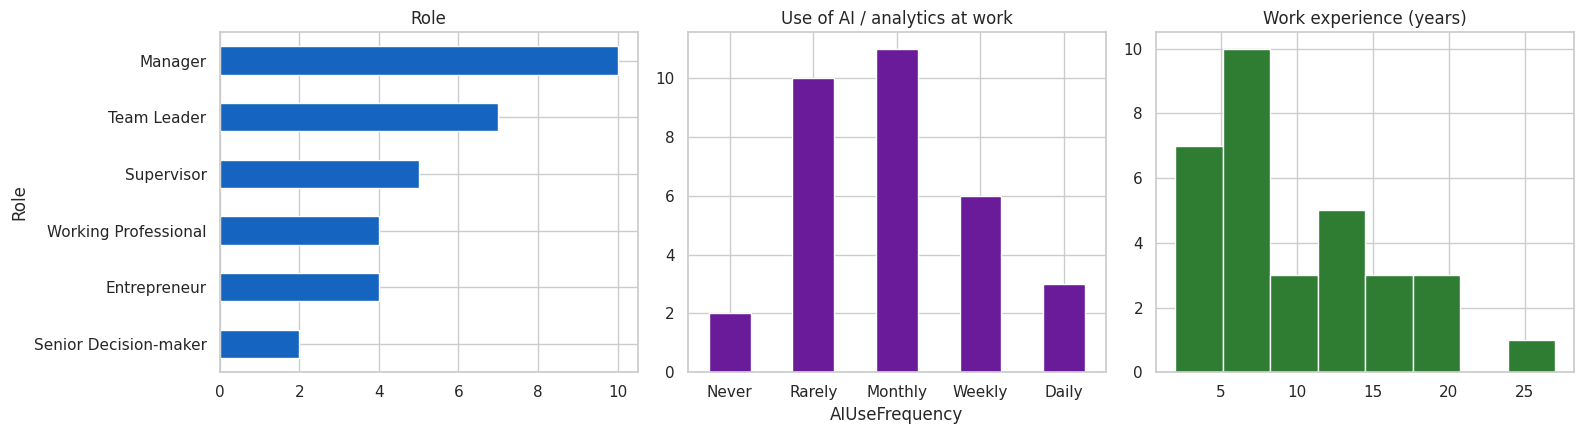

Median experience: 8 years | Sectors: 8 | Used tool themselves: 56%


Sector,Banking & NBFC,Consulting,Cooperative & Agri,FMCG,Healthcare,IT services,Manufacturing,Retail
Role,,,,,,,,
Entrepreneur,1,0,1,0,0,1,0,1
Manager,2,0,1,1,2,1,1,2
Senior Decision-maker,1,0,1,0,0,0,0,0
Supervisor,1,1,0,0,1,2,0,0
Team Leader,1,0,3,0,0,1,2,0
Working Professional,1,0,0,1,0,2,0,0


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
df.Role.value_counts().plot.barh(ax=ax[0], color="#1565c0"); ax[0].set_title("Role"); ax[0].invert_yaxis()
order = ["Never", "Rarely", "Monthly", "Weekly", "Daily"]
df.AIUseFrequency.value_counts().reindex(order).fillna(0).plot.bar(ax=ax[1], color="#6a1b9a")
ax[1].set_title("Use of AI / analytics at work"); ax[1].tick_params(axis="x", rotation=0)
ax[2].hist(df.ExperienceYears, bins=8, color="#2e7d32"); ax[2].set_title("Work experience (years)")
plt.tight_layout(); plt.show()

print(f"Median experience: {df.ExperienceYears.median():.0f} years | "
      f"Sectors: {df.Sector.nunique()} | Used tool themselves: {(df.ReviewMode=='Used it myself').mean():.0%}")
pd.crosstab(df.Role, df.Sector)

## 3. Likert items

In [3]:
CONSTRUCTS = {
    "Usefulness": ["PU1", "PU2", "PU3"], "Ease of use": ["EU1", "EU2"],
    "Trust": ["TR1", "TR2", "TR3"], "Explainability": ["EX1", "EX2"],
    "Fear of wrong decision": ["FR1", "FR2"], "Preference for intuition": ["IN1", "IN2"],
    "Org. support": ["OS1", "OS2"], "Intention to use": ["BI1", "BI2"],
}
ITEM_TEXT = {
    "PU1": "Helps spot at-risk employees earlier", "PU2": "Pay check is useful",
    "PU3": "Improves my retention decisions", "EU1": "Easy without technical knowledge",
    "EU2": "Risk levels are clear", "TR1": "I trust the risk score", "TR2": "I'd rely on it to decide",
    "TR3": "Accuracy is good enough", "EX1": "Seeing 'why' makes me more willing",
    "EX2": "Won't use what I can't explain", "FR1": "Worry about blame if AI is wrong",
    "FR2": "Fear makes me cautious", "IN1": "My experience beats a model",
    "IN2": "I'd go with my judgement", "OS1": "Org has the clean data",
    "OS2": "Org encourages AI use", "BI1": "I would use this tool", "BI2": "I'd recommend it",
}
items = [i for v in CONSTRUCTS.values() for i in v]
desc = pd.DataFrame({
    "statement": [ITEM_TEXT[i] for i in items],
    "mean": df[items].mean().round(2), "sd": df[items].std().round(2),
    "% agree (4-5)": (df[items] >= 4).mean().mul(100).round(0),
    "% disagree (1-2)": (df[items] <= 2).mean().mul(100).round(0),
})
desc

,statement,mean,sd,% agree (4-5),% disagree (1-2)
PU1,Helps spot at-risk employees earlier,3.78,0.61,69.0,0.0
PU2,Pay check is useful,3.53,0.67,56.0,6.0
PU3,Improves my retention decisions,3.62,0.55,66.0,3.0
EU1,Easy without technical knowledge,4.12,0.61,88.0,0.0
EU2,Risk levels are clear,4.19,0.59,91.0,0.0
TR1,I trust the risk score,3.16,0.68,31.0,16.0
TR2,I'd rely on it to decide,2.94,0.80,19.0,25.0
TR3,Accuracy is good enough,3.31,0.78,44.0,16.0
EX1,Seeing 'why' makes me more willing,4.19,0.82,81.0,3.0
EX2,Won't use what I can't explain,3.84,0.72,72.0,3.0


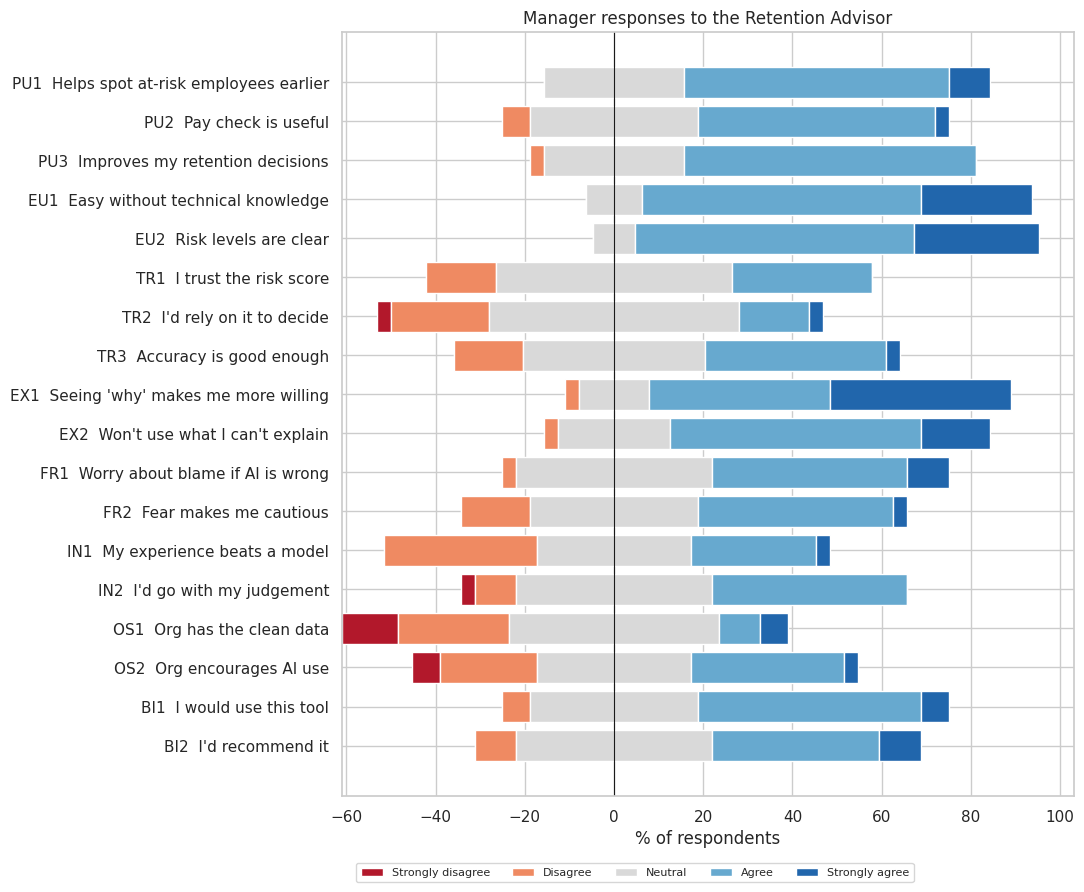

In [4]:
# Diverging stacked bar chart
cols = {1: "#b2182b", 2: "#ef8a62", 3: "#d9d9d9", 4: "#67a9cf", 5: "#2166ac"}
pct = pd.DataFrame({k: (df[items] == k).mean() * 100 for k in range(1, 6)})
pct.index = [f"{i}  {ITEM_TEXT[i]}" for i in items]
left = -(pct[1] + pct[2] + pct[3] / 2)
fig, ax = plt.subplots(figsize=(11, 9))
start = left.copy()
for k in range(1, 6):
    ax.barh(pct.index, pct[k], left=start, color=cols[k],
            label=["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"][k-1])
    start += pct[k]
ax.axvline(0, color="k", lw=.8); ax.invert_yaxis(); ax.set_xlabel("% of respondents")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(.4, -.12), fontsize=8)
ax.set_title("Manager responses to the Retention Advisor"); plt.tight_layout(); plt.show()

## 4. Construct scores and reliability (Cronbach's α)

In [5]:
def cronbach_alpha(x: pd.DataFrame) -> float:
    k = x.shape[1]
    return k / (k - 1) * (1 - x.var(ddof=1).sum() / x.sum(axis=1).var(ddof=1))

for c, its in CONSTRUCTS.items():
    df[c] = df[its].mean(axis=1)

rel = pd.DataFrame({
    "items": [len(v) for v in CONSTRUCTS.values()],
    "alpha": [cronbach_alpha(df[v]) for v in CONSTRUCTS.values()],
    "mean": [df[c].mean() for c in CONSTRUCTS], "sd": [df[c].std() for c in CONSTRUCTS],
}, index=list(CONSTRUCTS)).round(2)
rel["reliability"] = pd.cut(rel.alpha, [-1, .6, .7, .8, 1], labels=["Poor", "Acceptable (exploratory)", "Good", "Very good"])
rel

,items,alpha,mean,sd,reliability
Usefulness,3,0.79,3.65,0.51,Good
Ease of use,2,0.64,4.16,0.51,Acceptable (exploratory)
Trust,3,0.79,3.14,0.63,Good
Explainability,2,0.82,4.02,0.71,Very good
Fear of wrong decision,2,0.79,3.47,0.68,Good
Preference for intuition,2,0.72,3.14,0.73,Good
Org. support,2,0.88,2.89,0.95,Very good
Intention to use,2,0.86,3.52,0.71,Very good


α ≥ 0.7 is conventionally good; 0.6–0.7 is acceptable for an exploratory study with 2–3 items per construct and a small sample.

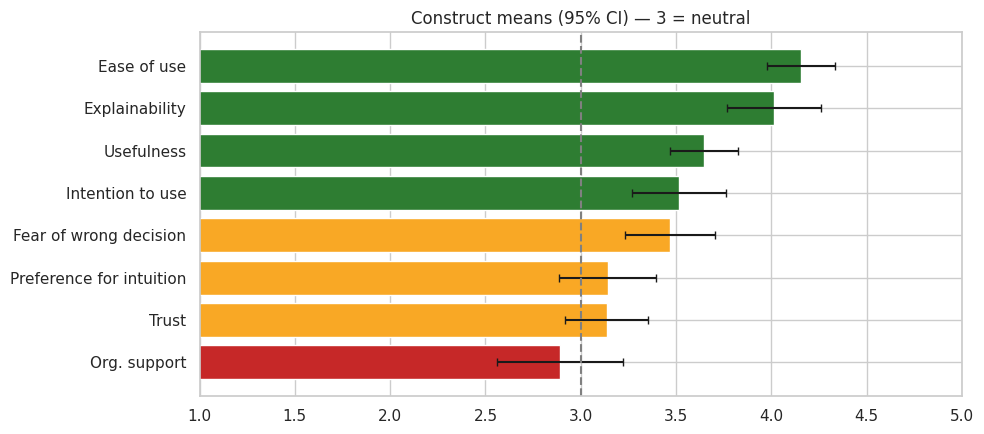

In [6]:
CON = list(CONSTRUCTS)
fig, ax = plt.subplots(figsize=(10, 4.5))
m = df[CON].mean().sort_values()
ax.barh(m.index, m, color=["#c62828" if v < 3 else "#f9a825" if v < 3.5 else "#2e7d32" for v in m],
        xerr=df[CON].std()[m.index] / np.sqrt(len(df)) * 1.96, capsize=3)
ax.axvline(3, ls="--", color="grey"); ax.set_xlim(1, 5); ax.set_title("Construct means (95% CI) — 3 = neutral")
plt.tight_layout(); plt.show()

## 5. Differences between groups

In [7]:
df["ExpGroup"] = pd.cut(df.ExperienceYears, [0, 7, 15, 40], labels=["≤7 yrs", "8–15 yrs", ">15 yrs"])
df["AIUser"] = np.where(df.AIUseFrequency.isin(["Weekly", "Daily"]), "Frequent AI user", "Occasional / non-user")

by_role = df.groupby("Role")[CON].mean().round(2)
by_role

,Usefulness,Ease of use,Trust,Explainability,Fear of wrong decision,Preference for intuition,Org. support,Intention to use
Role,,,,,,,,
Entrepreneur,3.42,4.38,2.92,3.38,3.25,3.50,3.88,4.00
Manager,3.60,3.95,3.30,4.05,3.50,3.25,2.85,3.85
Senior Decision-maker,4.00,4.25,2.83,4.00,4.00,3.75,1.75,3.00
Supervisor,3.80,4.20,3.53,4.40,3.40,2.80,2.40,3.30
Team Leader,3.71,4.36,3.00,4.14,3.21,2.79,2.71,3.29
Working Professional,3.50,4.00,2.83,3.88,3.88,3.25,3.50,3.12


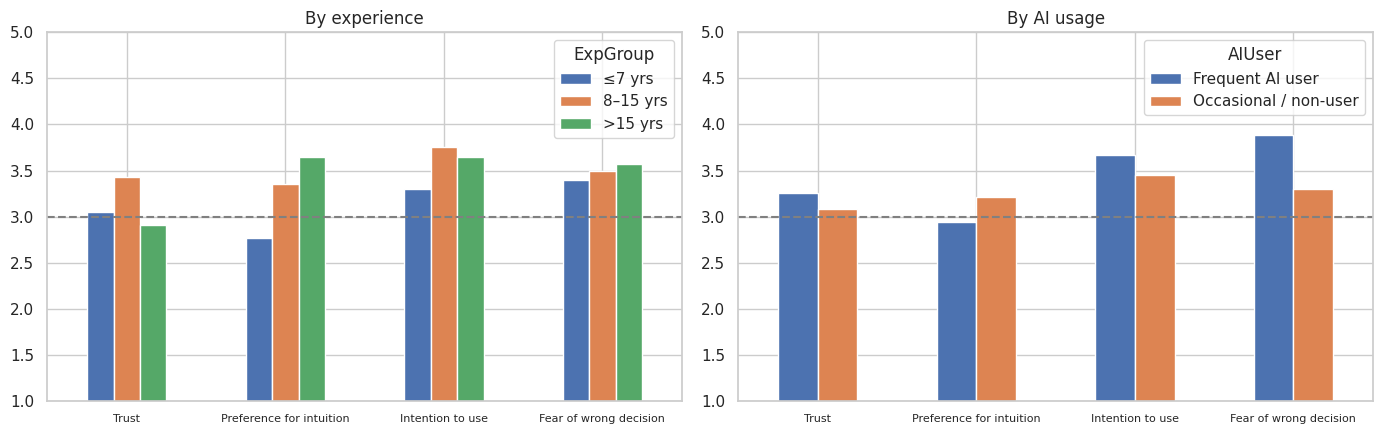

,construct,AI users mean,others mean,Mann-Whitney p,Experience Kruskal-Wallis p
0,Usefulness,3.778,3.594,0.311,0.995
1,Ease of use,4.556,4.000,0.005,0.221
2,Trust,3.259,3.087,0.524,0.165
3,Explainability,4.500,3.826,0.011,0.775
4,Fear of wrong decision,3.889,3.304,0.029,0.893
5,Preference for intuition,2.944,3.217,0.441,0.021
6,Org. support,2.889,2.891,1.000,0.699
7,Intention to use,3.667,3.457,0.633,0.218


In [8]:
key = ["Trust", "Preference for intuition", "Intention to use", "Fear of wrong decision"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
df.groupby("ExpGroup", observed=True)[key].mean().T.plot.bar(ax=ax[0], rot=0); ax[0].set_title("By experience"); ax[0].set_ylim(1, 5)
df.groupby("AIUser")[key].mean().T.plot.bar(ax=ax[1], rot=0); ax[1].set_title("By AI usage"); ax[1].set_ylim(1, 5)
for a in ax: a.axhline(3, ls="--", color="grey"); a.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

rows = []
for c in CON:
    g = [df.loc[df.AIUser == k, c] for k in ["Frequent AI user", "Occasional / non-user"]]
    u = stats.mannwhitneyu(*g)
    e = [df.loc[df.ExpGroup == k, c] for k in df.ExpGroup.cat.categories]
    kw = stats.kruskal(*e)
    rows.append({"construct": c, "AI users mean": g[0].mean(), "others mean": g[1].mean(),
                 "Mann-Whitney p": u.pvalue, "Experience Kruskal-Wallis p": kw.pvalue})
tests = pd.DataFrame(rows).round(3)
tests

Non-parametric tests are used because Likert scores are ordinal and the groups are small. With n = 32, treat p-values as indicative, not conclusive.

## 6. What drives the intention to use the tool?

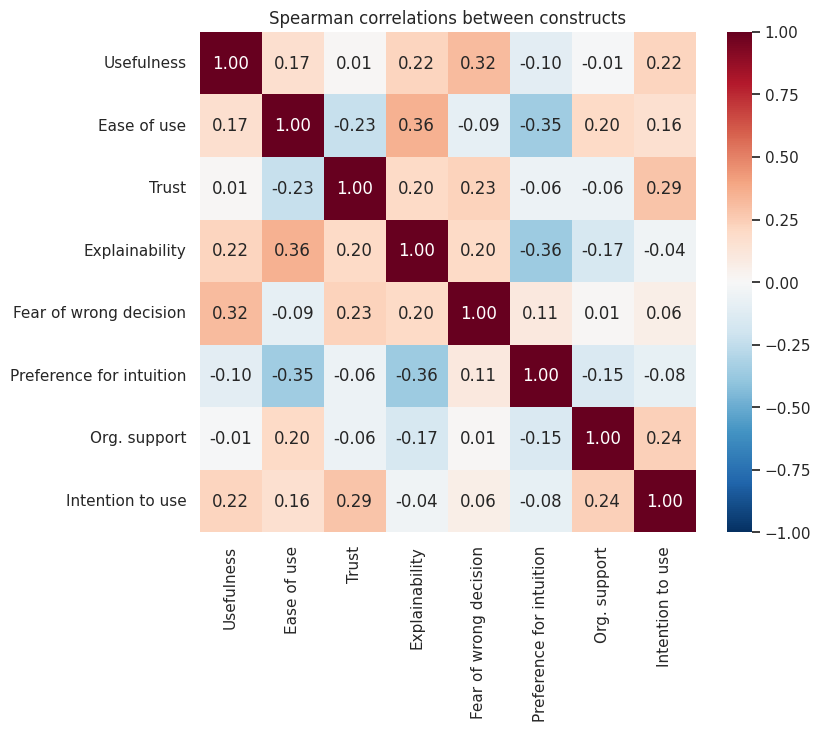

In [9]:
corr = df[CON].corr(method="spearman")
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlations between constructs"); plt.show()

In [10]:
reg = df.rename(columns=lambda c: c.replace(" ", "_").replace(".", ""))
model = smf.ols("Intention_to_use ~ Usefulness + Trust + Explainability + Fear_of_wrong_decision"
                " + Preference_for_intuition + Org_support", data=reg).fit()
print(model.summary().tables[1])
print(f"\nR² = {model.rsquared:.2f}, adj. R² = {model.rsquared_adj:.2f}, n = {int(model.nobs)}")

                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.8641      1.513      0.571      0.573      -2.252       3.980
Usefulness                   0.6290      0.235      2.682      0.013       0.146       1.112
Trust                        0.4048      0.199      2.035      0.053      -0.005       0.814
Explainability              -0.2027      0.194     -1.044      0.306      -0.603       0.197
Fear_of_wrong_decision      -0.0680      0.187     -0.364      0.719      -0.452       0.316
Preference_for_intuition    -0.0999      0.183     -0.546      0.590      -0.476       0.277
Org_support                  0.1565      0.127      1.230      0.230      -0.106       0.419

R² = 0.34, adj. R² = 0.18, n = 32


With 32 respondents and 6 predictors this regression is **exploratory** — it shows the direction and relative size of each factor, which we then check against what managers wrote in the open-ended answers.

## 7. Scenario: AI says 72% risk, your experience says the employee is loyal

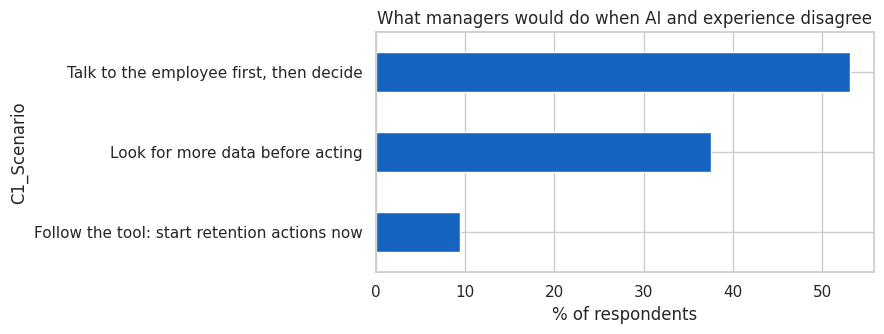

IntuitionLevel,High intuition preference,Low / moderate,All
C1_Scenario,,,
Follow the tool: start retention actions now,2,1,3
Look for more data before acting,6,6,12
"Talk to the employee first, then decide",8,9,17
All,16,16,32


In [11]:
sc = df.C1_Scenario.value_counts()
fig, ax = plt.subplots(figsize=(9, 3.5))
(sc / len(df) * 100).sort_values().plot.barh(ax=ax, color="#1565c0"); ax.set_xlabel("% of respondents")
ax.set_title("What managers would do when AI and experience disagree"); plt.tight_layout(); plt.show()

df["IntuitionLevel"] = np.where(df["Preference for intuition"] >= 3.5, "High intuition preference", "Low / moderate")
pd.crosstab(df.C1_Scenario, df.IntuitionLevel, margins=True)

## 8. Qualitative analysis of open-ended answers

**Method.** The open-ended questions are analysed in two groups:
- **Q1–Q7 (feedback on the tool)** — managers raise whatever matters to them, so these are coded into 9 cross-cutting themes and counted **once per respondent per theme**. This shows what managers bring up *unprompted*.
- **Q8–Q11 (prompted questions on intuition, explainability, fear and barriers)** — each already names a theme, so counting that theme would be circular. Instead each answer is coded into question-specific categories (reasons, stance, barriers).

Coding uses keyword rules (below). This is a transparent, repeatable version of manual thematic coding — when you have real data, read through the coded answers and adjust the keywords where the rules miss or over-match.

In [12]:
QTEXT = {
    "Q1": "How useful is the tool for managers?", "Q2": "Would you use it? Why?",
    "Q3": "What do you like?", "Q4": "What do you dislike / find missing?",
    "Q5": "Do you trust the prediction? Why?", "Q6": "What would make you trust AI more?",
    "Q7": "If AI and experience differ, what would you do?", "Q8": "Why do managers prefer intuition?",
    "Q9": "Does explainability matter?", "Q10": "Does fear of a wrong decision matter?",
    "Q11": "What discourages AI adoption?",
}
THEMES = {
    "Explainability & transparency": r"\bwhy\b|reason|explain|driver|black box|transparen|how the model|how it works|plain language|doesn't just give",
    "Data quality & integration": r"\bdata\b|hrms|record|garbage|input|manual|updated|outdated|integrat|disconnected",
    "Accountability & fear of blame": r"blame|accountab|mistake|targeted|fear|remembered",
    "Context & human judgement": r"context|personal|family|relationship|know my people|my experience|intuition|local|complex|judgement|special case|behaviour|conflict|market",
    "Validation & track record": r"track record|tested|pilot|validat|past cases|past data|been right|few months|six months|re-check",
    "Ease of use & workflow": r"easy|simple|layout|fields|too much work|\btime\b|mobile|csv|format|fast|burden|overloaded|another tool|without any training",
    "Actionability": r"action|what-if|overtime|prioriti|conversation|1:1|stay-interview|early|focus|flag",
    "Privacy, fairness & ethics": r"privacy|profiled|gender|bias|numbers|cold|audit|fairness|safeguard",
    "Organisational support & culture": r"management|policy|training|approve|culture|senior|budget|\bhr\b|boss|hierarch|guideline|literacy",
}
QCOLS = list(QTEXT)
TOOL_Q = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7"]
long = df.melt(id_vars=["RespondentID", "Role"], value_vars=TOOL_Q, var_name="Question", value_name="Answer")
for t, pat in THEMES.items():
    long[t] = long.Answer.str.contains(pat, flags=re.I, regex=True)

per_resp = long.groupby("RespondentID")[list(THEMES)].any()
theme_freq = (per_resp.mean() * 100).sort_values(ascending=False).round(0).to_frame("% of respondents")
theme_freq["mentions"] = long[list(THEMES)].sum()
theme_freq

,% of respondents,mentions
Data quality & integration,81.0,40
Explainability & transparency,78.0,41
Organisational support & culture,78.0,52
Actionability,72.0,51
Validation & track record,69.0,32
"Privacy, fairness & ethics",62.0,23
Context & human judgement,59.0,26
Ease of use & workflow,56.0,24
Accountability & fear of blame,3.0,1


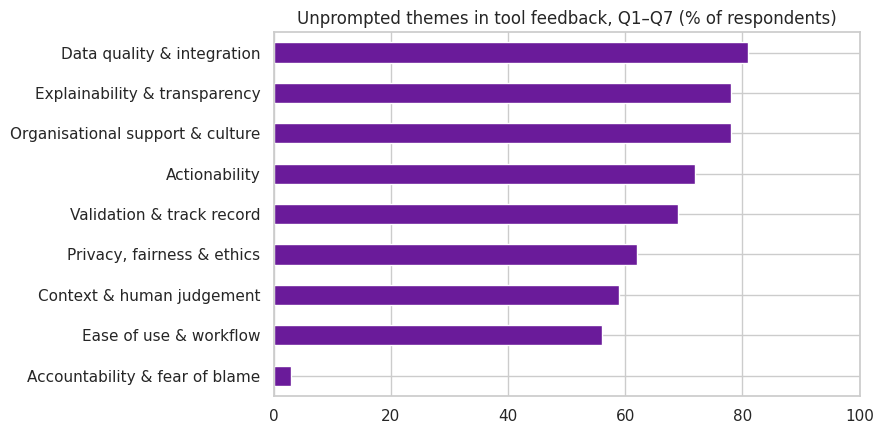

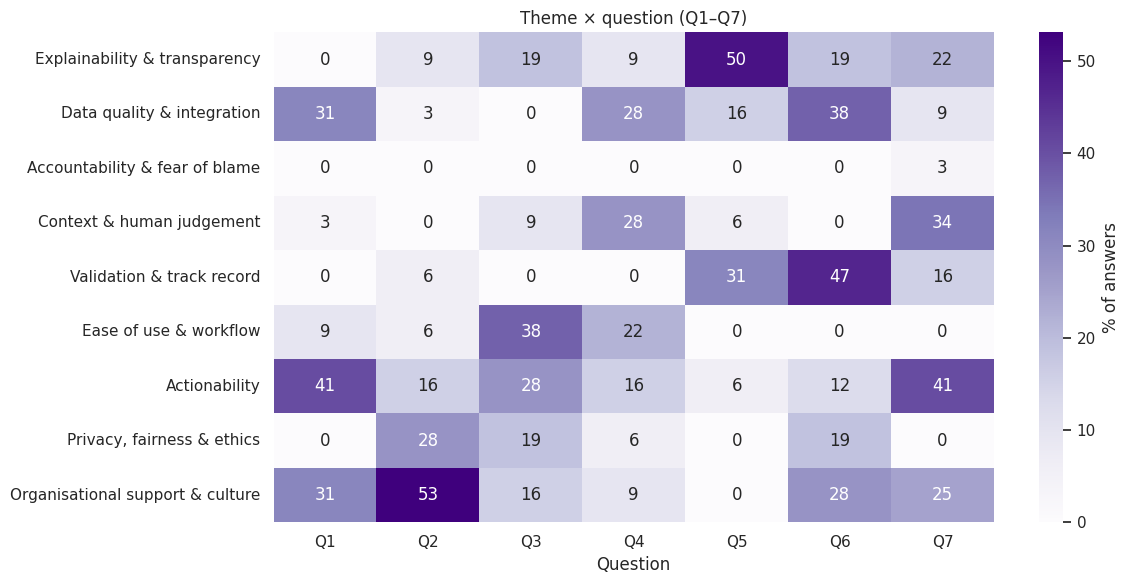

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
theme_freq["% of respondents"].sort_values().plot.barh(ax=ax, color="#6a1b9a")
ax.set_title("Unprompted themes in tool feedback, Q1–Q7 (% of respondents)"); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

# Which themes come up in which question
heat = long.groupby("Question")[list(THEMES)].mean().reindex(TOOL_Q) * 100
plt.figure(figsize=(12, 6))
sns.heatmap(heat.T, annot=True, fmt=".0f", cmap="Purples", cbar_kws={"label": "% of answers"})
plt.title("Theme × question (Q1–Q7)"); plt.tight_layout(); plt.show()

In [14]:
# Q2: would you use it? — simple stance coding
def stance(a):
    a = a.lower()
    if re.match(r"^(yes|i would|definitely)", a): return "Yes"
    if re.match(r"^(no|not|probably not)", a): return "No / not yet"
    return "Conditional / maybe"
df["Q2_stance"] = df.Q2.apply(stance)
print(df.Q2_stance.value_counts())
print()
print(pd.crosstab(df.Q2_stance, df.AIUser))
print()
print("Mean intention-to-use score by stance (checks consistency of closed vs open answers):")
print(df.groupby("Q2_stance")["Intention to use"].mean().round(2))

Q2_stance
Conditional / maybe    21
Yes                     7
No / not yet            4
Name: count, dtype: int64

AIUser               Frequent AI user  Occasional / non-user
Q2_stance                                                   
Conditional / maybe                 5                     16
No / not yet                        1                      3
Yes                                 3                      4

Mean intention-to-use score by stance (checks consistency of closed vs open answers):
Q2_stance
Conditional / maybe    3.45
No / not yet           2.50
Yes                    4.29
Name: Intention to use, dtype: float64


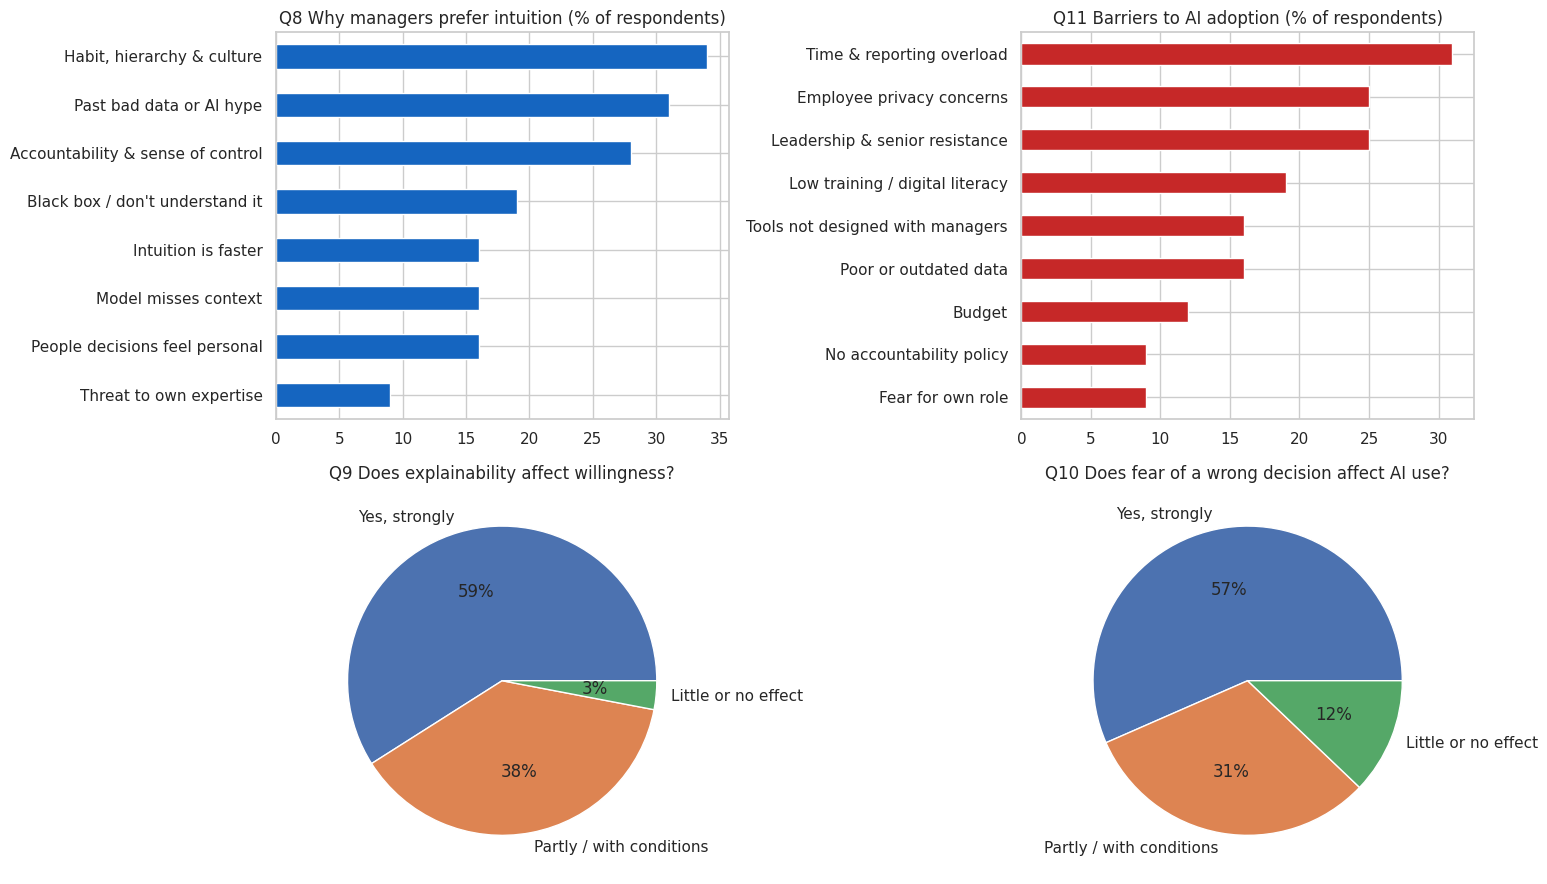

% of respondents
Q8 reasons for intuition   Habit, hierarchy & culture                     34.0
                           Past bad data or AI hype                       31.0
                           Accountability & sense of control              28.0
                           Black box / don't understand it                19.0
                           Model misses context                           16.0
                           Intuition is faster                            16.0
                           People decisions feel personal                 16.0
                           Threat to own expertise                         9.0
Q9 explainability          Yes, strongly                                  59.0
                           Partly / with conditions                       38.0
                           Little or no effect                             3.0
Q10 fear of wrong decision Yes, strongly                                  56.0
                           Partly / with conditions                       31.0
                           Little or no effect                            12.0
Q11 barriers               Time & reporting overload                      31.0
                           Employee privacy concerns                      25.0
                           Leadership & senior resistance                 25.0
                           Low training / digital literacy                19.0
                           Poor or outdated data                          16.0
                           Tools not designed with managers               16.0
                           Budget                                         12.0
                           Fear for own role                               9.0
                           No accountability policy                        9.0

In [15]:
# Q8–Q11: question-specific coding
Q8_CODES = {
    "Accountability & sense of control": r"accountab|control|blame",
    "Model misses context": r"context|family|politics|offers",
    "Habit, hierarchy & culture": r"habit|culture|boss|old ways|careers",
    "Black box / don't understand it": r"black box|understand",
    "Threat to own expertise": r"threat|expertise",
    "Past bad data or AI hype": r"bad data|wrong reports|hype|sceptical|the one case",
    "Intuition is faster": r"faster|needs inputs",
    "People decisions feel personal": r"number feels cold|personal, and",
}
Q11_CODES = {
    "Poor or outdated data": r"data quality|outdated|hr records",
    "Low training / digital literacy": r"training|literacy",
    "Leadership & senior resistance": r"top management|senior people|old ways",
    "Employee privacy concerns": r"privacy|resist being scored",
    "Time & reporting overload": r"lack of time|overloaded|one more tool|disconnected",
    "Fear for own role": r"job loss|manager's role",
    "Budget": r"budget",
    "No accountability policy": r"accountable|policy",
    "Tools not designed with managers": r"built by it|what they need",
}
def code_multi(series, codes):
    hits = pd.DataFrame({k: series.str.contains(v, case=False, regex=True) for k, v in codes.items()})
    return (hits.mean() * 100).round(0).sort_values(ascending=False)

def stance3(a, yes=r"^(yes|definitely)", partly=r"^(somewhat|a little|it does|it matters|yes, but)"):
    a = a.lower()
    if re.match(r"^yes, but", a) or re.match(partly, a): return "Partly / with conditions"
    if re.match(yes, a): return "Yes, strongly"
    return "Little or no effect"

q8 = code_multi(df.Q8, Q8_CODES)
q11 = code_multi(df.Q11, Q11_CODES)
df["Q9_stance"] = df.Q9.apply(stance3)
df["Q10_stance"] = df.Q10.apply(stance3)
q9 = (df.Q9_stance.value_counts(normalize=True) * 100).round(0)
q10 = (df.Q10_stance.value_counts(normalize=True) * 100).round(0)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
q8.sort_values().plot.barh(ax=ax[0, 0], color="#1565c0"); ax[0, 0].set_title("Q8 Why managers prefer intuition (% of respondents)")
q11.sort_values().plot.barh(ax=ax[0, 1], color="#c62828"); ax[0, 1].set_title("Q11 Barriers to AI adoption (% of respondents)")
q9.plot.pie(ax=ax[1, 0], autopct="%.0f%%", ylabel=""); ax[1, 0].set_title("Q9 Does explainability affect willingness?")
q10.plot.pie(ax=ax[1, 1], autopct="%.0f%%", ylabel=""); ax[1, 1].set_title("Q10 Does fear of a wrong decision affect AI use?")
plt.tight_layout(); plt.show()

prompted = pd.concat({"Q8 reasons for intuition": q8, "Q9 explainability": q9,
                      "Q10 fear of wrong decision": q10, "Q11 barriers": q11}).rename("% of respondents").to_frame()
prompted

In [16]:
# Representative quotes per theme (shortest clear answers first)
pd.set_option("display.max_colwidth", 160)
quotes = []
for t in theme_freq.index:
    hits = long[long[t]].assign(n=lambda d: d.Answer.str.len()).sort_values("n")
    for _, r in hits.drop_duplicates("Answer").head(3).iterrows():
        quotes.append({"theme": t, "respondent": f"{r.RespondentID} ({r.Role})", "question": r.Question, "quote": r.Answer})
quotes = pd.DataFrame(quotes)
quotes

,theme,respondent,question,quote
0,Data quality & integration,R06 (Entrepreneur),Q4,I wanted to know how recent the training data is.
1,Data quality & integration,R08 (Team Leader),Q6,Regular updates of the model with our latest data.
2,Data quality & integration,R22 (Team Leader),Q4,Data privacy is not addressed — who sees these scores?
3,Explainability & transparency,R10 (Supervisor),Q3,The drivers list is helpful.
4,Explainability & transparency,R05 (Entrepreneur),Q5,"Reasonably, but I would never act on it alone."
5,Explainability & transparency,R28 (Manager),Q6,Transparency on the data it uses and privacy safeguards.
6,Organisational support & culture,R05 (Entrepreneur),Q7,Flag it to HR and let them take a neutral view.
7,Organisational support & culture,R06 (Entrepreneur),Q4,I wanted to know how recent the training data is.
8,Organisational support & culture,R04 (Entrepreneur),Q6,Being validated by HR and approved by management.
9,Actionability,R03 (Working Professional),Q4,Some suggested actions are generic.


## 9. Export results

In [17]:
from openpyxl.styles import Font, PatternFill, Alignment

out = "survey_analysis.xlsx"
codebook = pd.DataFrame(
    [(c, i, ITEM_TEXT[i]) for c, its in CONSTRUCTS.items() for i in its] +
    [("Open-ended", q, t) for q, t in QTEXT.items()] +
    [("Scenario", "C1_Scenario", "AI says 72% risk; experience says loyal. What would you do?")],
    columns=["construct", "code", "question"])

with pd.ExcelWriter(out, engine="openpyxl") as xw:
    df.drop(columns=CON + ["ExpGroup", "AIUser", "IntuitionLevel", "Q2_stance", "Q9_stance", "Q10_stance"]).to_excel(xw, sheet_name="Responses", index=False)
    codebook.to_excel(xw, sheet_name="Codebook", index=False)
    desc.to_excel(xw, sheet_name="Likert items")
    rel.to_excel(xw, sheet_name="Constructs & alpha")
    by_role.to_excel(xw, sheet_name="By role")
    tests.to_excel(xw, sheet_name="Group tests", index=False)
    pd.DataFrame({"coef": model.params, "p_value": model.pvalues}).round(3).to_excel(xw, sheet_name="Regression")
    pd.crosstab(df.C1_Scenario, df.IntuitionLevel, margins=True).to_excel(xw, sheet_name="Scenario")
    theme_freq.to_excel(xw, sheet_name="Themes")
    prompted.to_excel(xw, sheet_name="Prompted Qs")
    quotes.to_excel(xw, sheet_name="Quotes", index=False)
    for ws in xw.book.worksheets:
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF"); cell.fill = PatternFill("solid", fgColor="1565C0")
        for col in ws.columns:
            width = min(max(len(str(c.value or "")) for c in col) + 2, 70)
            ws.column_dimensions[col[0].column_letter].width = width
            for c in col[1:]:
                c.alignment = Alignment(wrap_text=width >= 70, vertical="top")
        ws.freeze_panes = "A2"
print("Saved", out)

Saved survey_analysis.xlsx


## 10. Findings

*(Numbers below describe the current dataset. If you replace it with real responses, update this section from the outputs above.)*

### What managers think of the tool
1. **Easy to use, but not yet trusted.** Ease of use scored highest (mean 4.2; ~90% agree the risk levels are clear), while trust scored close to neutral (3.1). Only **19% would rely on the prediction to decide**, and a quarter actively disagreed.
2. **Useful as an early-warning system.** 69% said it helps spot at-risk employees earlier. The pay benchmark was valued less (56%) — consistent with the model finding that pay gaps alone don't predict attrition.
3. **Adoption is conditional.** 56% would use the tool, but in open answers **two-thirds gave a conditional "maybe"**: *if* it pulls data from the HRMS, *if* HR/management approves it, *if* it proves itself on their own people.

### What drives willingness to use AI
4. **Usefulness and trust drive intention** (regression: usefulness β = 0.63, p = 0.01; trust β = 0.40, p ≈ 0.05). This mirrors the Technology Acceptance Model: people adopt tools they find useful, provided they trust them.
5. **Explainability is a precondition, not a differentiator.** 81% said seeing the reasons makes them more willing, and only 1 respondent said explanations don't matter. Because almost everyone rates it high, it doesn't separate adopters from non-adopters in the regression — it is a *hygiene factor*: without it, the tool would be rejected outright.
6. **Managers treat AI as a trigger for inquiry, not a verdict.** When the AI and their experience disagreed, only **9% would follow the tool**, while **53% would talk to the employee first** and **38% would look for more data**. Nobody chose to ignore the score entirely. Managers want *augmentation, not automation*.
7. **Fear of blame is real.** 53% worry about being blamed for acting on a wrong prediction; in open answers the recurring point was *"I'll be blamed, not the AI."* Interestingly, frequent AI users reported **more** caution (3.9 vs 3.3, p = 0.03) — possibly because they know how often models err.
8. **Experience strengthens intuition.** Preference for one's own judgement rose with years of experience (Kruskal-Wallis p = 0.02). Reasons given: habit and hierarchy, past experiences with bad data or AI hype, and the need to stay in control when accountable.

### Barriers
9. **Organisational readiness is the weakest link** (mean 2.9, lowest of all constructs). Only 16% said their organisation has the clean data such a tool needs. Named barriers: time and report overload, employee privacy, resistance from senior leaders, and low training.
10. **Unprompted concerns (Q1–Q7)** centred on data quality/integration (81% of respondents), explainability (78%), organisational support (78%), actionability (72%) and proof of a track record (69%).

### Implications for the tool and for managers
| Finding | Change to the tool / rollout |
|---|---|
| Trust is low; managers want proof | Add a "track record" page showing past predictions vs outcomes in *our* company; pilot in one department first |
| Data entry is a burden | Connect to the HRMS so scores update automatically |
| Exact % feels over-precise | Show a range and the risk band; keep the ranking view |
| Fear of blame | Company guideline: the score *triggers a conversation*, the manager owns the decision |
| Privacy concerns | State who sees scores; never share them with the employee's peers; exclude sensitive attributes (already done for gender) |
| Explanations are essential | Keep the drivers list; add a one-line plain-English summary per employee |

### Limitations
- **The responses in this notebook are synthetic** and must be replaced with real survey data before drawing conclusions.
- n = 32 is small; regression and group tests are exploratory.
- Self-reported intentions often overstate actual use.
- Keyword-based coding is a first pass; real answers should be read and the coding frame refined.